# Notebook 04 — DQN vs PPO/MaskablePPO Comparison on Multiphase Workload

Notebook này dùng để **train DQN (Deep Q-Network – mạng Q học sâu)** như một **DRL comparison baseline (baseline học tăng cường sâu để so sánh)** với **PPO/MaskablePPO v8.1** trong đồ án Cloud Energy Management.

Mục tiêu chính:
- Train DQN trên `workload_real_multiphase.csv` với cùng môi trường, reward và config v8.1 của PPO.
- Evaluate `DQN_raw` và `DQN_masked_eval` để thấy rõ ảnh hưởng của invalid actions (hành động không hợp lệ).
- So sánh DQN với heuristic baselines: Fixed-Keep, RoundRobin, Threshold, BestFit.
- Tự đọc kết quả PPO seed66 nếu đã có trong `outputs/v8_1/multiphase/` để tạo bảng **PPO vs DQN**.
- Xuất bảng/figure dạng report-ready để đưa vào báo cáo.

Cách dùng khuyến nghị:
1. Copy notebook này vào thư mục `notebooks/` của project.
2. Chạy từ trên xuống.
3. Muốn chạy nhanh: đặt `DQN_TIMESTEPS = 500_000`.
4. Muốn so sánh nghiêm túc hơn: giữ `DQN_TIMESTEPS = 1_000_000`.
5. Muốn công bằng nhất với PPO 2.5M: đổi `DQN_TIMESTEPS = 2_500_000`.

Lưu ý quan trọng khi viết báo cáo:
- `DQN_raw`: DQN chọn action bình thường, không action mask; dùng để phân tích kỹ thuật, **không nên đưa vào bảng chính**.
- `DQN_masked_eval`: dùng Q-value của DQN nhưng chặn action không hợp lệ bằng `env.action_masks()` trong lúc evaluate; đây là dòng nên dùng để so với PPO.
- `PPO/MaskablePPO`: được action masking trong cả training/evaluation, nên phù hợp hơn với môi trường có nhiều invalid actions.
- Nếu số timestep của DQN khác PPO, hãy ghi rõ DQN là **comparison baseline / supplementary experiment**, không phải so sánh tuyệt đối hoàn toàn công bằng.


In [1]:
from __future__ import annotations

import json
import math
import os
import re
import sys
from dataclasses import asdict, replace
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


def find_project_root(start: Path | None = None) -> Path:
    """Tìm project root bằng cách đi ngược lên tới khi thấy src/ và data/."""
    start = Path.cwd() if start is None else Path(start)
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "src").exists() and (p / "data").exists():
            return p
    if start.name == "notebooks" and (start.parent / "src").exists() and (start.parent / "data").exists():
        return start.parent
    raise FileNotFoundError(
        "Không tìm thấy project root có thư mục src/ và data/. "
        "Hãy đặt notebook này trong thư mục notebooks/ rồi chạy."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = c:\Users\PHUONG NGHI\Desktop\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD


## 1. Cấu hình chạy DQN

Mặc định dùng `seed66` vì bạn đang dùng seed66 làm đại diện để so sánh với PPO.

Mình để mặc định `DQN_TIMESTEPS = 1_000_000` để kết quả đỡ bị xem là quá sơ bộ. Nếu máy yếu hoặc cần test nhanh, đổi về `500_000`. Nếu muốn công bằng nhất với PPO seed66 2.5M, đổi thành `2_500_000`.

`FORCE_RETRAIN = False` nghĩa là nếu model DQN đã tồn tại trong đúng `RUN_DIR`, notebook sẽ load lại để evaluate, không train lại từ đầu.


In [2]:
SEED = 66
DQN_TIMESTEPS =  2_500_000         # Gợi ý: 500_000 để test nhanh, 1_000_000 để so sánh ổn hơn, 2_500_000 để match PPO.
FORCE_RETRAIN = False              # False = nếu có model_dqn.zip thì load lại, tránh train lại mất thời gian.
TRAIN_EPISODE_LENGTH = 320
USE_VM_SNAPSHOT_FOR_MULTIPHASE = True

WORKLOAD_CSV = PROJECT_ROOT / "data" / "workload_real_multiphase.csv"
VM_SNAPSHOT_CSV = PROJECT_ROOT / "data" / "vm_snapshots.csv"

EXPERIMENT_NAME = f"dqn_vs_ppo_multiphase_seed{SEED}_{DQN_TIMESTEPS}"
RUN_DIR = PROJECT_ROOT / "outputs" / "dqn_vs_ppo_comparison" / EXPERIMENT_NAME
FIG_DIR = RUN_DIR / "figures"
TRACE_DIR = RUN_DIR / "traces"
for d in [RUN_DIR, FIG_DIR, TRACE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("RUN_DIR =", RUN_DIR)
print("WORKLOAD_CSV exists:", WORKLOAD_CSV.exists(), WORKLOAD_CSV)
print("VM_SNAPSHOT_CSV exists:", VM_SNAPSHOT_CSV.exists(), VM_SNAPSHOT_CSV)
print("FORCE_RETRAIN =", FORCE_RETRAIN)


RUN_DIR = c:\Users\PHUONG NGHI\Desktop\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\outputs\dqn_vs_ppo_comparison\dqn_vs_ppo_multiphase_seed66_2500000
WORKLOAD_CSV exists: True c:\Users\PHUONG NGHI\Desktop\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\data\workload_real_multiphase.csv
VM_SNAPSHOT_CSV exists: True c:\Users\PHUONG NGHI\Desktop\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\data\vm_snapshots.csv
FORCE_RETRAIN = False


## 2. Load workload multiphase và tạo phase start indices

In [3]:
if not WORKLOAD_CSV.exists():
    raise FileNotFoundError(f"Không tìm thấy workload: {WORKLOAD_CSV}")

workload_df = pd.read_csv(WORKLOAD_CSV).reset_index(drop=True)
if "demand" not in workload_df.columns:
    raise ValueError("workload_real_multiphase.csv phải có cột demand")

# Chuẩn hóa/suy luận phase nếu file chưa có phase hoặc phase bị lỗi.
if "phase" not in workload_df.columns:
    workload_df["phase"] = pd.cut(
        workload_df["demand"].astype(float),
        bins=[-np.inf, 0.40, 0.75, np.inf],
        labels=["low", "medium", "high"],
    ).astype(str)
else:
    workload_df["phase"] = workload_df["phase"].astype(str).str.lower().str.strip()
    valid = {"low", "medium", "high"}
    bad_mask = ~workload_df["phase"].isin(valid)
    if bad_mask.any():
        workload_df.loc[bad_mask, "phase"] = pd.cut(
            workload_df.loc[bad_mask, "demand"].astype(float),
            bins=[-np.inf, 0.40, 0.75, np.inf],
            labels=["low", "medium", "high"],
        ).astype(str)

workload = workload_df["demand"].astype(float).to_numpy()

phase_summary = (
    workload_df.groupby("phase", observed=False)["demand"]
    .agg(["count", "min", "mean", "max", "std"])
    .reindex(["low", "medium", "high"])
)
display(phase_summary)

required_phases = {"low", "medium", "high"}
actual_phases = set(workload_df["phase"].dropna().unique())
missing = required_phases - actual_phases
if missing:
    raise ValueError(f"Thiếu phase: {missing}")

if (phase_summary["count"] < TRAIN_EPISODE_LENGTH).any():
    raise ValueError(f"Có phase ngắn hơn TRAIN_EPISODE_LENGTH={TRAIN_EPISODE_LENGTH}")

print("Workload có đủ low/medium/high và mỗi phase đủ dài.")


def find_phase_segments(df: pd.DataFrame, phase_col: str = "phase") -> pd.DataFrame:
    rows = []
    start = 0
    for i in range(1, len(df)):
        if df.loc[i, phase_col] != df.loc[i - 1, phase_col]:
            rows.append({
                "phase": str(df.loc[start, phase_col]),
                "start": int(start),
                "end": int(i - 1),
                "length": int(i - start),
            })
            start = i
    rows.append({
        "phase": str(df.loc[start, phase_col]),
        "start": int(start),
        "end": int(len(df) - 1),
        "length": int(len(df) - start),
    })
    return pd.DataFrame(rows)


def build_phase_start_indices(df: pd.DataFrame, episode_length: int, phase_col: str = "phase") -> dict[str, list[int]]:
    segs = find_phase_segments(df, phase_col=phase_col)
    phase_starts: dict[str, list[int]] = {}
    for phase in ["low", "medium", "high"]:
        starts: list[int] = []
        phase_segs = segs[segs["phase"] == phase]
        for _, row in phase_segs.iterrows():
            max_start = int(row["end"]) - episode_length
            if max_start >= int(row["start"]):
                starts.extend(list(range(int(row["start"]), max_start + 1)))
        phase_starts[phase] = starts
    return phase_starts


PHASE_SEGMENTS = find_phase_segments(workload_df)
PHASE_STARTS = build_phase_start_indices(workload_df, TRAIN_EPISODE_LENGTH)

print("Phase segments:")
display(PHASE_SEGMENTS)
print("Phase start counts:", {k: len(v) for k, v in PHASE_STARTS.items()})

if any(len(v) == 0 for v in PHASE_STARTS.values()):
    raise ValueError("Có phase không tạo được start index. Hãy kiểm tra workload hoặc TRAIN_EPISODE_LENGTH.")

with open(RUN_DIR / "phase_start_indices_dqn.json", "w", encoding="utf-8") as f:
    json.dump(PHASE_STARTS, f, ensure_ascii=False, indent=2)

,count,min,mean,max,std
phase,,,,,
low,1141,0.150000,0.262934,0.399790,0.076733
medium,649,0.400208,0.531602,0.748998,0.099162
high,370,0.750899,0.957857,1.100000,0.107460


Workload có đủ low/medium/high và mỗi phase đủ dài.
Phase segments:


,phase,start,end,length
0,high,0,369,370
1,medium,370,1018,649
2,low,1019,2159,1141


Phase start counts: {'low': 821, 'medium': 329, 'high': 50}


## 3. Import environment, baselines và cấu hình reward v8.1

In [4]:
from src.energy_env_v8_1 import CloudEnergyEnv, EnvConfig, load_workload_csv
from src.baselines import FixedPolicy, RoundRobinPolicy, ThresholdPolicy, BestFitPolicy, RandomValidPolicy

workload_env = load_workload_csv(str(WORKLOAD_CSV))
assert len(workload_env) == len(workload)

# Reward/config copy theo Notebook 02 v8_1 để DQN so sánh cùng môi trường với PPO.
REWARD_OVERRIDES = dict(
    max_hosts=8,
    host_nominal_capacity=1.0 / 7.0,

    reward_w_energy=2.50,
    reward_w_sla=4.35,
    reward_w_latency=0.35,
    reward_w_migration=0.22,
    reward_w_switch=0.09,

    reward_w_overprovision=1.48,
    reward_w_active_excess=1.78,
    reward_w_sleep_excess=0.28,
    reward_w_low_active_excess=0.98,
    reward_w_sticky_config=0.10,

    reward_w_conditional_inaction=0.18,
    reward_w_macro_scale_down_action=0.06,
    reward_w_macro_power_off_action=0.05,
    inaction_demand_threshold=0.56,
    inaction_transition_drop_threshold=0.030,
    inaction_active_margin=1,
    macro_scale_down_demand_threshold=0.62,
    macro_power_off_demand_threshold=0.50,
    macro_active_margin=1,
    macro_max_switches_per_step=1,
    macro_block_if_demand_rising=True,
    macro_demand_rise_threshold=0.035,

    reward_w_dvfs=0.46,
    reward_w_dvfs_mismatch=0.74,
    reward_w_temp=0.34,
    reward_w_lifetime=0.12,
    reward_w_pue=0.055,
    reward_w_cooling=0.12,

    reward_w_power_off_action=0.08,
    reward_w_safe_off_state=0.018,
    reward_w_off_shortage=0.52,
    reward_w_low_transition_action=0.16,
    reward_w_low_scale_down_action=0.10,
    low_load_threshold=0.55,
    low_active_margin=1,

    reward_w_high_load_sleep_off=0.42,
    high_load_threshold=0.75,
    high_load_min_desired_active=7,
    mask_sleep_off_in_high_load=True,

    reward_w_hot_util=0.38,
    hot_util_temp_threshold_c=55.0,
    hot_util_util_threshold=0.86,
    reward_w_high_temp_under_dvfs=0.34,
    reward_w_hot_dvfs_up_action=0.10,
    high_temp_under_dvfs_threshold_c=58.0,
    placement_thermal_weight=0.035,
    placement_hot_util_weight=0.040,
    placement_target_util_for_temp=0.86,

    power_off_bonus_sla_threshold=0.030,
    power_off_bonus_spare_threshold=0.055,
    power_off_bonus_demand_rise_threshold=0.04,

    reward_w_sla_guard=0.48,
    sla_guard_threshold=0.02,
    use_smooth_sla_penalty=True,
    migration_keep_tolerance=0.075,
    migration_norm_scale=120.0,

    dvfs_levels=(0.6, 0.8, 1.0),
    power_dvfs_exponent=3.0,

    obs_include_demand_trend=True,
    obs_demand_trend_offset=3,
    randomize_dvfs_init_by_demand=True,
)

vm_snapshot_path = str(VM_SNAPSHOT_CSV) if (USE_VM_SNAPSHOT_FOR_MULTIPHASE and VM_SNAPSHOT_CSV.exists()) else None
print("vm_snapshot_path =", vm_snapshot_path)

base_train_config = EnvConfig(
    episode_length=TRAIN_EPISODE_LENGTH,
    seed=SEED,
    vm_snapshot_path=vm_snapshot_path,
    balanced_phase_reset=True,
    phase_start_indices=PHASE_STARTS,
    phase_sampling_order=("low", "medium", "high"),
    phase_sampling_probs=(1/3, 1/3, 1/3),
    **REWARD_OVERRIDES,
)

# Smoke test môi trường.
smoke_env = CloudEnergyEnv(workload_env, base_train_config)
rows = []
for i in range(9):
    obs, _ = smoke_env.reset(seed=SEED + i)
    rows.append({
        "i": i,
        "start_idx": smoke_env.start_idx,
        "reset_phase": smoke_env.last_reset_phase,
        "obs_shape": tuple(obs.shape),
        "action_space_n": smoke_env.action_space.n,
        "dvfs_init": smoke_env.dvfs,
        "demand0": smoke_env._get_demand(0),
        "active_init": smoke_env.active_hosts,
        "sleep_init": smoke_env.sleep_hosts,
        "off_init": smoke_env.off_hosts,
        "mask": smoke_env.action_masks().astype(int).tolist(),
    })
smoke_df = pd.DataFrame(rows)
display(smoke_df)

assert smoke_df["reset_phase"].isin(["low", "medium", "high"]).all()
assert smoke_env.action_space.n == 9
print("Env smoke test passed.")

vm_snapshot_path = c:\Users\PHUONG NGHI\Desktop\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\data\vm_snapshots.csv


,i,start_idx,reset_phase,obs_shape,action_space_n,dvfs_init,demand0,active_init,sleep_init,off_init,mask
0,0,12,high,"(19,)",9,1.0,1.099394,7,1,0,"[1, 1, 0, 0, 1, 0, 0, 0, 0]"
1,1,553,medium,"(19,)",9,0.8,0.591380,7,1,0,"[1, 1, 1, 1, 1, 1, 0, 0, 0]"
2,2,548,medium,"(19,)",9,1.0,0.597000,6,1,1,"[1, 1, 1, 0, 1, 1, 1, 0, 0]"
3,3,592,medium,"(19,)",9,1.0,0.582544,5,1,2,"[1, 1, 1, 0, 1, 1, 1, 0, 0]"
4,4,475,medium,"(19,)",9,1.0,0.651641,6,1,1,"[1, 1, 1, 0, 1, 1, 1, 0, 0]"
5,5,1405,low,"(19,)",9,0.8,0.297796,4,1,3,"[1, 1, 1, 1, 1, 1, 1, 0, 1]"
6,6,30,high,"(19,)",9,1.0,1.100000,7,1,0,"[1, 1, 0, 0, 1, 0, 0, 0, 0]"
7,7,627,medium,"(19,)",9,0.8,0.567795,7,1,0,"[1, 1, 1, 1, 1, 1, 0, 0, 0]"
8,8,18,high,"(19,)",9,1.0,1.100000,7,1,0,"[1, 1, 0, 0, 1, 0, 0, 0, 0]"


Env smoke test passed.


## 4. Train DQN

DQN ở đây là baseline phụ. Nếu chạy 500k thấy kết quả chưa ổn, bạn có thể tăng `DQN_TIMESTEPS` lên `1_000_000`.

In [5]:
try:
    import torch
    from stable_baselines3 import DQN
    from stable_baselines3.common.monitor import Monitor
except Exception as e:
    raise ImportError(
        "Thiếu thư viện train. Hãy cài: pip install stable-baselines3 torch tensorboard"
    ) from e


def make_train_env(seed: int = SEED):
    cfg = replace(base_train_config, seed=seed)
    env = CloudEnergyEnv(workload_env, cfg)
    return Monitor(env)


train_env = make_train_env(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

DQN_HYPERPARAMS = dict(
    learning_rate=1e-4,
    buffer_size=150_000,              # tăng nhẹ so với 100k để lưu trải nghiệm đa dạng hơn
    learning_starts=15_000,
    batch_size=128,
    gamma=0.995,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=2_000,
    exploration_fraction=0.35,        # exploration dài hơn một chút vì môi trường có nhiều action
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    policy_kwargs=dict(net_arch=[128, 128]),
)

model_path = RUN_DIR / "model_dqn.zip"

if model_path.exists() and not FORCE_RETRAIN:
    print("Tìm thấy model DQN cũ, load lại để evaluate:", model_path)
    model_dqn = DQN.load(str(model_path), env=train_env, device=device)
else:
    print("Không load model cũ hoặc FORCE_RETRAIN=True. Bắt đầu train DQN:", DQN_TIMESTEPS, "timesteps")
    model_dqn = DQN(
        "MlpPolicy",
        train_env,
        tensorboard_log=str(RUN_DIR / "tb"),
        seed=SEED,
        device=device,
        verbose=1,
        **DQN_HYPERPARAMS,
    )

    config_dump = {
        "algorithm": "DQN",
        "note": "DQN comparison baseline; training không dùng action masking như MaskablePPO.",
        "SEED": SEED,
        "DQN_TIMESTEPS": DQN_TIMESTEPS,
        "FORCE_RETRAIN": FORCE_RETRAIN,
        "TRAIN_EPISODE_LENGTH": TRAIN_EPISODE_LENGTH,
        "USE_VM_SNAPSHOT_FOR_MULTIPHASE": USE_VM_SNAPSHOT_FOR_MULTIPHASE,
        "REWARD_OVERRIDES": {k: (list(v) if isinstance(v, tuple) else v) for k, v in REWARD_OVERRIDES.items()},
        "base_train_config": {k: str(v) if isinstance(v, Path) else v for k, v in asdict(base_train_config).items() if k != "phase_start_indices"},
        "phase_start_counts": {k: len(v) for k, v in PHASE_STARTS.items()},
        "dqn_hyperparams": {
            **{k: v for k, v in DQN_HYPERPARAMS.items() if k != "policy_kwargs"},
            "net_arch": DQN_HYPERPARAMS["policy_kwargs"]["net_arch"],
        },
    }
    with open(RUN_DIR / "config_dqn_vs_ppo.json", "w", encoding="utf-8") as f:
        json.dump(config_dump, f, ensure_ascii=False, indent=2)

    model_dqn.learn(total_timesteps=DQN_TIMESTEPS, tb_log_name=EXPERIMENT_NAME, progress_bar=False)
    model_dqn.save(str(model_path))
    print("Saved DQN model:", model_path)


Using device: cpu
Không load model cũ hoặc FORCE_RETRAIN=True. Bắt đầu train DQN: 2500000 timesteps
Using cpu device
Wrapping the env in a DummyVecEnv.
Logging to c:\Users\PHUONG NGHI\Desktop\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\outputs\dqn_vs_ppo_comparison\dqn_vs_ppo_multiphase_seed66_2500000\tb\dqn_vs_ppo_multiphase_seed66_2500000_1
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 320       |
|    ep_rew_mean      | -1.61e+03 |
|    exploration_rate | 0.999     |
| time/               |           |
|    episodes         | 4         |
|    fps              | 457       |
|    time_elapsed     | 2         |
|    total_timesteps  | 1280      |
-----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 320       |
|    ep_rew_mean      | -1.66e+03 |
|    exploration_rate | 0.997     |
| time/               |           |
|    episodes         | 8         |
|  

## 5. Evaluation helpers

In [6]:
ACTION_NAMES = getattr(CloudEnergyEnv, "ACTION_NAMES", {})


def make_eval_env(episode_length: int, seed: int = SEED) -> CloudEnergyEnv:
    cfg = EnvConfig(
        episode_length=episode_length,
        seed=seed,
        vm_snapshot_path=vm_snapshot_path,
        balanced_phase_reset=False,
        phase_start_indices=PHASE_STARTS,
        **REWARD_OVERRIDES,
    )
    return CloudEnergyEnv(workload_env, cfg)


def predict_dqn_masked(model: DQN, env: CloudEnergyEnv, obs: np.ndarray) -> int:
    """Chọn action có Q-value cao nhất trong các action hợp lệ theo env.action_masks()."""
    action_mask = np.asarray(env.action_masks(), dtype=bool)
    if action_mask.sum() == 0:
        action, _ = model.predict(obs, deterministic=True)
        return int(np.asarray(action).item())

    with torch.no_grad():
        obs_tensor, _ = model.policy.obs_to_tensor(obs)
        q_values = model.q_net(obs_tensor).detach().cpu().numpy()[0]

    q_values = q_values.copy()
    q_values[~action_mask] = -1e9
    return int(np.argmax(q_values))


def predict_action(policy_name: str, policy: Any, env: CloudEnergyEnv, obs: np.ndarray, deterministic: bool = True) -> int:
    action_mask = env.action_masks() if hasattr(env, "action_masks") else None

    if policy_name == "DQN_masked_eval":
        return predict_dqn_masked(policy, env, obs)

    if isinstance(policy, RandomValidPolicy):
        action, _ = policy.predict(obs, action_mask=action_mask)
        return int(np.asarray(action).item())

    # DQN_raw hoặc các model SB3 khác.
    if hasattr(policy, "policy"):
        action, _ = policy.predict(obs, deterministic=deterministic)
        return int(np.asarray(action).item())

    # Heuristic baselines.
    try:
        action, _ = policy.predict(obs)
    except TypeError:
        action, _ = policy.predict(obs, action_mask=action_mask)
    return int(np.asarray(action).item())


def trace_to_dataframe(trace: list[dict[str, Any]], policy_name: str) -> pd.DataFrame:
    rows = []
    for local_step, item in enumerate(trace):
        global_t = int(item.get("global_timestep", local_step))
        phase = str(workload_df.loc[global_t, "phase"]) if 0 <= global_t < len(workload_df) else "unknown"
        row = {
            "policy": policy_name,
            "step": local_step,
            "global_timestep": global_t,
            "phase": phase,
            "demand": float(item.get("demand", 0.0)),
            "power_it": float(item.get("power_it", 0.0)),
            "power_total": float(item.get("power_total", item.get("power", 0.0))),
            "pue": float(item.get("pue", 1.0)),
            "cooling_power": float(item.get("cooling_power", 0.0)),
            "sla_violation": float(item.get("sla_violation", item.get("sla", 0.0))),
            "active_hosts": int(item.get("active_hosts", 0)),
            "sleep_hosts": int(item.get("sleep_hosts", 0)),
            "off_hosts": int(item.get("off_hosts", 0)),
            "dvfs": float(item.get("dvfs", 0.0)),
            "mean_util": float(item.get("mean_util", 0.0)),
            "avg_temp": float(item.get("avg_temp", 0.0)),
            "max_temp": float(item.get("max_temp", 0.0)),
            "migrations": int(item.get("migrations", 0)),
            "migration_cost": float(item.get("migration_cost", 0.0)),
            "switches": int(item.get("switches", 0)),
            "action": int(item.get("action", -1)),
            "action_name": str(item.get("action_name", ACTION_NAMES.get(int(item.get("action", -1)), "UNKNOWN"))),
            "action_valid": bool(item.get("action_valid", True)),
            "reward_total": float(item.get("reward_total", 0.0)),
            "uses_vm_snapshots": bool(item.get("uses_vm_snapshots", False)),
        }
        for k, v in (item.get("reward_groups", {}) or {}).items():
            row[f"reward_group_{k}"] = float(v)
        for k, v in (item.get("reward_weighted_components", {}) or {}).items():
            row[f"reward_weighted_{k}"] = float(v)
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_trace(df: pd.DataFrame, policy_name: str) -> dict[str, Any]:
    action_counts = df["action_name"].value_counts().to_dict() if "action_name" in df.columns else {}
    return {
        "policy": policy_name,
        "steps": int(len(df)),
        "uses_vm_snapshots": bool(df["uses_vm_snapshots"].any()) if "uses_vm_snapshots" in df.columns else False,
        "total_energy": float(df["power_total"].sum()),
        "total_it_energy": float(df["power_it"].sum()),
        "avg_power": float(df["power_total"].mean()),
        "avg_pue": float(df["pue"].mean()),
        "avg_sla": float(df["sla_violation"].mean()),
        "max_sla": float(df["sla_violation"].max()),
        "sla_step_rate": float((df["sla_violation"] > 1e-6).mean()),
        "avg_active_hosts": float(df["active_hosts"].mean()),
        "avg_sleep_hosts": float(df["sleep_hosts"].mean()),
        "avg_off_hosts": float(df["off_hosts"].mean()),
        "avg_dvfs": float(df["dvfs"].mean()),
        "avg_temp": float(df["avg_temp"].mean()),
        "max_temp": float(df["max_temp"].max()),
        "total_migrations": int(df["migrations"].sum()),
        "total_migration_cost": float(df["migration_cost"].sum()),
        "total_switches": int(df["switches"].sum()),
        "invalid_action_rate": float((~df["action_valid"].astype(bool)).mean()) if "action_valid" in df.columns else np.nan,
        "keep_rate": float((df["action_name"] == "KEEP").mean()),
        "power_off_count": int((df["action_name"] == "POWER_OFF_ONE").sum()),
        "sleep_count": int((df["action_name"] == "SLEEP_ONE").sum()),
        "wake_count": int((df["action_name"] == "WAKE_ONE").sum()),
        "boot_count": int((df["action_name"] == "BOOT_ONE").sum()),
        "scale_down_excess_count": int((df["action_name"] == "SCALE_DOWN_EXCESS").sum()),
        "power_off_excess_count": int((df["action_name"] == "POWER_OFF_EXCESS").sum()),
        "dvfs_down_count": int((df["action_name"] == "DVFS_DOWN").sum()),
        "dvfs_up_count": int((df["action_name"] == "DVFS_UP").sum()),
        "distinct_actions": int(df["action_name"].nunique()),
        "action_counts_json": json.dumps(action_counts, ensure_ascii=False),
    }


def run_policy_episode(policy_name: str, policy: Any, episode_length: int, start_idx: int = 0, phase_label: str = "full") -> tuple[pd.DataFrame, dict[str, Any]]:
    env = make_eval_env(episode_length=episode_length, seed=SEED)
    obs, _ = env.reset(seed=SEED, options={"start_idx": int(start_idx), "phase": phase_label})
    done = False
    total_reward = 0.0

    while not done:
        action = predict_action(policy_name, policy, env, obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += float(reward)
        done = bool(terminated or truncated)

    df = trace_to_dataframe(env.trace, policy_name)
    summary = summarize_trace(df, policy_name)
    summary["episode_length"] = episode_length
    summary["start_idx"] = start_idx
    summary["phase_label"] = phase_label
    summary["total_reward_from_loop"] = total_reward
    return df, summary

## 6. Evaluate DQN và heuristic baselines trên full multiphase workload

In [7]:
FULL_EVAL_LENGTH = len(workload_env) - 1

policies = {
    "DQN_raw": model_dqn,
    "DQN_masked_eval": model_dqn,
    "Fixed-Keep": FixedPolicy(action=0),
    "RoundRobin": RoundRobinPolicy(),
    "Threshold": ThresholdPolicy(high=0.85, low=0.25),
    "BestFit": BestFitPolicy(target_util=0.70),
    "RandomValid": RandomValidPolicy(seed=SEED),
}

full_traces: dict[str, pd.DataFrame] = {}
full_summaries: list[dict[str, Any]] = []

for name, policy in policies.items():
    print("Evaluating full workload:", name)
    df_trace, summary = run_policy_episode(name, policy, episode_length=FULL_EVAL_LENGTH, start_idx=0, phase_label="full")
    full_traces[name] = df_trace
    full_summaries.append(summary)
    df_trace.to_csv(TRACE_DIR / f"full_trace_{name}.csv", index=False)

results_df = pd.DataFrame(full_summaries).sort_values("total_energy")
results_df.to_csv(RUN_DIR / "evaluation_results_dqn_baseline.csv", index=False)
display(results_df)

all_trace_df = pd.concat(full_traces.values(), ignore_index=True)
all_trace_df.to_csv(RUN_DIR / "all_traces_dqn_baseline.csv", index=False)
print("Saved results to:", RUN_DIR)

Evaluating full workload: DQN_raw


Evaluating full workload: DQN_masked_eval
Evaluating full workload: Fixed-Keep
Evaluating full workload: RoundRobin
Evaluating full workload: Threshold
Evaluating full workload: BestFit
Evaluating full workload: RandomValid


,policy,steps,uses_vm_snapshots,total_energy,total_it_energy,avg_power,avg_pue,avg_sla,max_sla,sla_step_rate,avg_active_hosts,avg_sleep_hosts,avg_off_hosts,avg_dvfs,avg_temp,max_temp,total_migrations,total_migration_cost,total_switches,invalid_action_rate,keep_rate,power_off_count,sleep_count,wake_count,boot_count,scale_down_excess_count,power_off_excess_count,dvfs_down_count,dvfs_up_count,distinct_actions,action_counts_json,episode_length,start_idx,phase_label,total_reward_from_loop
6,RandomValid,2159,True,2.083043e+06,1.485584e+06,964.818279,1.404755,0.064415,0.775545,0.251042,5.496526,0.790644,1.71283,0.795646,46.229884,66.996323,70668,7803.594390,1074,0.000000,0.219083,155,307,161,248,106,97,306,306,9,"{""KEEP"": 473, ""SLEEP_ONE"": 307, ""DVFS_DOWN"": 3...",2159,0,full,-8756.143556
1,DQN_masked_eval,2159,True,2.083436e+06,1.420229e+06,965.000299,1.492282,0.085719,0.478894,0.522927,3.611394,4.388606,0.00000,0.915980,44.044867,66.999992,39534,1134.948727,20,0.000000,0.162112,0,13,7,0,0,0,895,894,5,"{""DVFS_DOWN"": 895, ""DVFS_UP"": 894, ""KEEP"": 350...",2159,0,full,-7681.941428
0,DQN_raw,2159,True,2.193387e+06,1.519704e+06,1015.927182,1.435771,0.030332,0.283643,0.265401,3.980547,4.019453,0.00000,0.962483,44.453428,66.999992,37375,1620.575782,68,0.618342,0.013895,0,36,32,50,0,45,377,1589,7,"{""DVFS_UP"": 1589, ""DVFS_DOWN"": 377, ""BOOT_ONE""...",2159,0,full,-7329.848508
5,BestFit,2159,True,2.396498e+06,1.720093e+06,1110.003659,1.397576,0.000000,0.000000,0.000000,5.529412,2.470588,0.00000,0.825753,47.260492,66.999992,562,77.835791,6,0.433997,0.562297,0,5,1,0,0,0,939,0,4,"{""KEEP"": 1214, ""DVFS_DOWN"": 939, ""SLEEP_ONE"": ...",2159,0,full,-7107.969079
3,RoundRobin,2159,True,2.622074e+06,1.923424e+06,1214.485506,1.377341,0.012834,0.310198,0.075961,6.666512,1.333488,0.00000,0.859101,48.021899,66.999992,34486,1071.407116,303,0.211672,0.647059,0,154,149,0,0,0,459,0,4,"{""KEEP"": 1397, ""DVFS_DOWN"": 459, ""SLEEP_ONE"": ...",2159,0,full,-9442.849641
4,Threshold,2159,True,2.670609e+06,1.964756e+06,1236.965920,1.373392,0.010233,0.257271,0.073182,6.668828,1.331172,0.00000,0.911348,47.911732,66.999992,27710,769.372524,313,0.089393,0.764706,0,159,154,0,0,0,195,0,4,"{""KEEP"": 1651, ""DVFS_DOWN"": 195, ""SLEEP_ONE"": ...",2159,0,full,-9954.365421
2,Fixed-Keep,2159,True,2.785342e+06,2.059208e+06,1290.107466,1.338653,0.005175,0.090909,0.060213,7.000000,1.000000,0.00000,1.000000,47.863355,66.999992,12925,473.707735,0,0.000000,1.000000,0,0,0,0,0,0,0,0,1,"{""KEEP"": 2159}",2159,0,full,-11121.576294


Saved results to: c:\Users\PHUONG NGHI\Desktop\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\outputs\dqn_vs_ppo_comparison\dqn_vs_ppo_multiphase_seed66_2500000


## 7. Tính energy saving của DQN so với RoundRobin/BestFit

Mình dùng `DQN_masked_eval` làm kết quả DQN chính vì nó tránh action không hợp lệ lúc evaluate. Khi báo cáo nhớ ghi rõ: **DQN được mask trong evaluation, còn PPO được mask cả trong training/evaluation**.

In [8]:
SELECTED_DQN_POLICY = "DQN_masked_eval"

dqn_energy = float(results_df.loc[results_df["policy"] == SELECTED_DQN_POLICY, "total_energy"].iloc[0])

saving_rows = []
for _, row in results_df.iterrows():
    baseline = row["policy"]
    if baseline.startswith("DQN"):
        continue
    baseline_energy = float(row["total_energy"])
    saving_rows.append({
        "dqn_policy": SELECTED_DQN_POLICY,
        "baseline": baseline,
        "baseline_energy": baseline_energy,
        "dqn_energy": dqn_energy,
        "energy_saving_pct": 100.0 * (baseline_energy - dqn_energy) / max(baseline_energy, 1e-9),
    })

energy_saving_df = pd.DataFrame(saving_rows).sort_values("energy_saving_pct", ascending=False)
energy_saving_df.to_csv(RUN_DIR / "energy_saving_dqn_vs_baselines.csv", index=False)
display(energy_saving_df)

# Kiểm tra nhanh mốc 10-15% với RoundRobin/BestFit.
for baseline in ["RoundRobin", "BestFit", "Threshold", "Fixed-Keep"]:
    row = energy_saving_df[energy_saving_df["baseline"] == baseline]
    if len(row):
        saving = float(row["energy_saving_pct"].iloc[0])
        print(f"{SELECTED_DQN_POLICY} saving vs {baseline}: {saving:.2f}%")

,dqn_policy,baseline,baseline_energy,dqn_energy,energy_saving_pct
4,DQN_masked_eval,Fixed-Keep,2.785342e+06,2.083436e+06,25.200007
3,DQN_masked_eval,Threshold,2.670609e+06,2.083436e+06,21.986509
2,DQN_masked_eval,RoundRobin,2.622074e+06,2.083436e+06,20.542461
1,DQN_masked_eval,BestFit,2.396498e+06,2.083436e+06,13.063323
0,DQN_masked_eval,RandomValid,2.083043e+06,2.083436e+06,-0.018866


DQN_masked_eval saving vs RoundRobin: 20.54%
DQN_masked_eval saving vs BestFit: 13.06%
DQN_masked_eval saving vs Threshold: 21.99%
DQN_masked_eval saving vs Fixed-Keep: 25.20%


## 8. Phân tích theo phase

In [9]:
phase_summary_rows = []
for policy_name, df in full_traces.items():
    for phase in ["low", "medium", "high"]:
        sub = df[df["phase"] == phase]
        if sub.empty:
            continue
        phase_summary_rows.append({
            "policy": policy_name,
            "phase": phase,
            "steps": int(len(sub)),
            "total_energy": float(sub["power_total"].sum()),
            "avg_power": float(sub["power_total"].mean()),
            "avg_sla": float(sub["sla_violation"].mean()),
            "sla_step_rate": float((sub["sla_violation"] > 1e-6).mean()),
            "avg_active_hosts": float(sub["active_hosts"].mean()),
            "avg_sleep_hosts": float(sub["sleep_hosts"].mean()),
            "avg_off_hosts": float(sub["off_hosts"].mean()),
            "avg_dvfs": float(sub["dvfs"].mean()),
            "avg_temp": float(sub["avg_temp"].mean()),
            "total_migrations": int(sub["migrations"].sum()),
            "keep_rate": float((sub["action_name"] == "KEEP").mean()),
            "distinct_actions": int(sub["action_name"].nunique()),
        })

phase_summary_df = pd.DataFrame(phase_summary_rows)
phase_summary_df.to_csv(RUN_DIR / "phase_summary_dqn_baseline.csv", index=False)
display(phase_summary_df)

# Bảng riêng cho DQN để đọc nhanh.
display(phase_summary_df[phase_summary_df["policy"].str.startswith("DQN")])

,policy,phase,steps,total_energy,avg_power,avg_sla,sla_step_rate,avg_active_hosts,avg_sleep_hosts,avg_off_hosts,avg_dvfs,avg_temp,total_migrations,keep_rate,distinct_actions
0,DQN_raw,low,1140,8.086207e+05,709.316438,0.005454,0.048246,3.000000,5.000000,0.000000,0.990351,38.305216,3603,0.000000,2
1,DQN_raw,medium,649,6.737115e+05,1038.076290,0.078997,0.619414,4.007704,3.992296,0.000000,0.898613,46.447697,25590,0.000000,4
2,DQN_raw,high,370,7.110545e+05,1921.769014,0.021622,0.313514,6.954054,1.045946,0.000000,0.988649,59.898508,8182,0.081081,7
3,DQN_masked_eval,low,1140,6.569397e+05,576.262907,0.117579,0.638596,1.959649,6.040351,0.000000,0.900351,36.926460,14639,0.000000,4
4,DQN_masked_eval,medium,649,6.739623e+05,1038.462671,0.078624,0.617874,4.010786,3.989214,0.000000,0.898613,46.483627,24725,0.000000,4
5,DQN_masked_eval,high,370,7.525337e+05,2033.874752,0.000000,0.000000,8.000000,0.000000,0.000000,0.994595,61.699540,170,0.945946,4
6,Fixed-Keep,low,1140,1.166242e+06,1023.019140,0.000000,0.000000,7.000000,1.000000,0.000000,1.000000,42.788109,0,1.000000,1
7,Fixed-Keep,medium,649,8.951610e+05,1379.292693,0.000000,0.000000,7.000000,1.000000,0.000000,1.000000,49.857292,0,1.000000,1
8,Fixed-Keep,high,370,7.239392e+05,1956.592547,0.030199,0.351351,7.000000,1.000000,0.000000,1.000000,60.003127,12925,1.000000,1
9,RoundRobin,low,1140,9.232698e+05,809.885812,0.024305,0.143860,5.474561,2.525439,0.000000,0.733158,41.917996,34321,0.332456,4


,policy,phase,steps,total_energy,avg_power,avg_sla,sla_step_rate,avg_active_hosts,avg_sleep_hosts,avg_off_hosts,avg_dvfs,avg_temp,total_migrations,keep_rate,distinct_actions
0,DQN_raw,low,1140,808620.739529,709.316438,0.005454,0.048246,3.000000,5.000000,0.0,0.990351,38.305216,3603,0.000000,2
1,DQN_raw,medium,649,673711.511950,1038.076290,0.078997,0.619414,4.007704,3.992296,0.0,0.898613,46.447697,25590,0.000000,4
2,DQN_raw,high,370,711054.535221,1921.769014,0.021622,0.313514,6.954054,1.045946,0.0,0.988649,59.898508,8182,0.081081,7
3,DQN_masked_eval,low,1140,656939.713779,576.262907,0.117579,0.638596,1.959649,6.040351,0.0,0.900351,36.926460,14639,0.000000,4
4,DQN_masked_eval,medium,649,673962.273328,1038.462671,0.078624,0.617874,4.010786,3.989214,0.0,0.898613,46.483627,24725,0.000000,4
5,DQN_masked_eval,high,370,752533.658293,2033.874752,0.000000,0.000000,8.000000,0.000000,0.0,0.994595,61.699540,170,0.945946,4


## 9. Plot nhanh kết quả chính

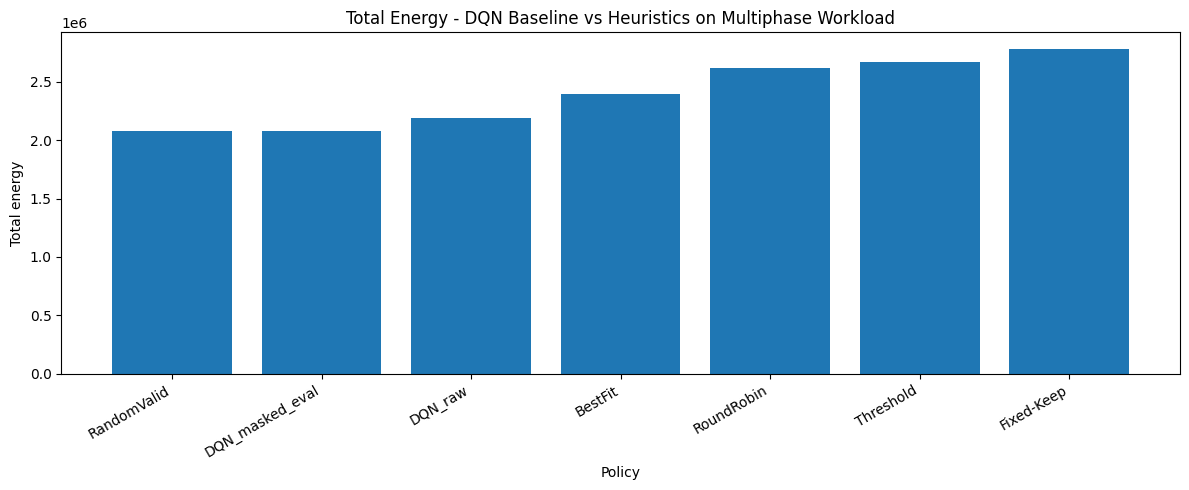

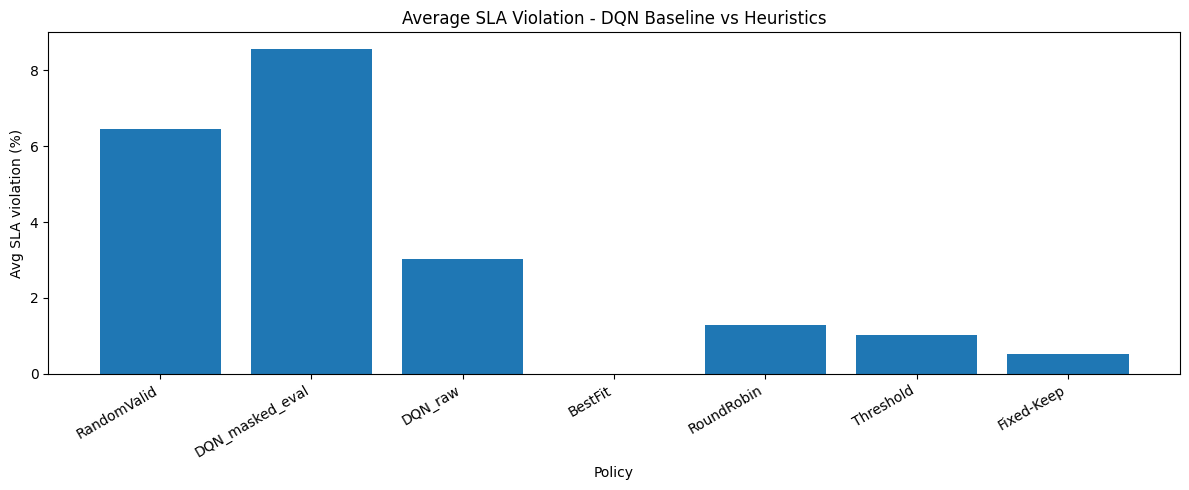

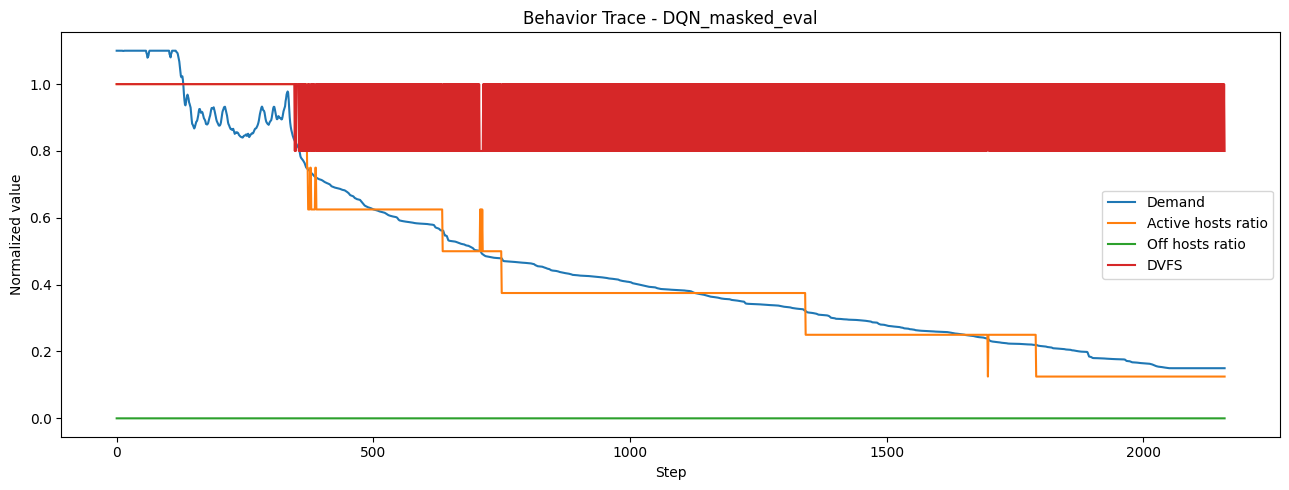

Saved figures to: c:\Users\PHUONG NGHI\Desktop\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\outputs\dqn_vs_ppo_comparison\dqn_vs_ppo_multiphase_seed66_2500000\figures


In [10]:
plot_df = results_df.copy().sort_values("total_energy")

plt.figure(figsize=(12, 5))
plt.bar(plot_df["policy"], plot_df["total_energy"])
plt.title("Total Energy - DQN Baseline vs Heuristics on Multiphase Workload")
plt.xlabel("Policy")
plt.ylabel("Total energy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_total_energy_dqn_vs_baselines.png", dpi=200)
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["policy"], plot_df["avg_sla"] * 100.0)
plt.title("Average SLA Violation - DQN Baseline vs Heuristics")
plt.xlabel("Policy")
plt.ylabel("Avg SLA violation (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_avg_sla_dqn_vs_baselines.png", dpi=200)
plt.show()

selected_trace = full_traces[SELECTED_DQN_POLICY]
plt.figure(figsize=(13, 5))
plt.plot(selected_trace["step"], selected_trace["demand"], label="Demand")
plt.plot(selected_trace["step"], selected_trace["active_hosts"] / REWARD_OVERRIDES["max_hosts"], label="Active hosts ratio")
plt.plot(selected_trace["step"], selected_trace["off_hosts"] / REWARD_OVERRIDES["max_hosts"], label="Off hosts ratio")
plt.plot(selected_trace["step"], selected_trace["dvfs"], label="DVFS")
plt.title(f"Behavior Trace - {SELECTED_DQN_POLICY}")
plt.xlabel("Step")
plt.ylabel("Normalized value")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_behavior_trace_selected_dqn.png", dpi=200)
plt.show()

print("Saved figures to:", FIG_DIR)

## 10. Đọc kết quả PPO seed66 nếu đã có sẵn để so sánh trực tiếp

Notebook sẽ tự tìm file `evaluation_results_v8_1.csv` của PPO seed66 trong `outputs/v8_1/multiphase/`.

Phần này tạo thêm:
- `dqn_vs_ppo_seed66_if_available.csv`: bảng raw DQN vs PPO.
- `main_drl_comparison_table_seed66.csv`: bảng đẹp hơn để đưa vào báo cáo.
- `dqn_vs_ppo_seed66_summary_metrics.csv`: các chênh lệch quan trọng như energy gap, SLA ratio, migration ratio.


In [11]:
def find_ppo_eval_csv(project_root: Path, seed: int = SEED) -> Path | None:
    patterns = [
        f"outputs/v8_1/multiphase/v8_1_multiphase_seed{seed}_*/evaluation_results_v8_1.csv",
        f"outputs/v8_1/multiphase_test/v8_1_multiphase_seed{seed}_*/evaluation_results_v8_1.csv",
        f"outputs/**/v8_1_multiphase_seed{seed}_*/evaluation_results_v8_1.csv",
    ]
    for pattern in patterns:
        matches = sorted(project_root.glob(pattern))
        if matches:
            return matches[-1]
    return None


def infer_timesteps_from_path(path: Path | None) -> int | None:
    if path is None:
        return None
    m = re.search(r"seed\d+_(\d+)", str(path))
    return int(m.group(1)) if m else None


def as_pct_fraction(x: float) -> float:
    """Convert fraction to percent for report tables."""
    return 100.0 * float(x)


ppo_eval_csv = find_ppo_eval_csv(PROJECT_ROOT, SEED)
print("PPO eval CSV:", ppo_eval_csv)

ppo_compare_available = False
ppo_train_timesteps = infer_timesteps_from_path(ppo_eval_csv)

if ppo_eval_csv is not None:
    ppo_eval_df = pd.read_csv(ppo_eval_csv)
    ppo_row = ppo_eval_df[ppo_eval_df["policy"].astype(str).str.contains("PPO", case=False, na=False)].copy()

    if len(ppo_row):
        ppo_compare_available = True
        ppo_row = ppo_row.iloc[[0]].copy()
        ppo_row["source_csv"] = str(ppo_eval_csv)

        dqn_row = results_df[results_df["policy"] == SELECTED_DQN_POLICY].copy()

        compare_cols = [
            "policy", "total_energy", "avg_sla", "sla_step_rate", "avg_pue",
            "avg_active_hosts", "avg_sleep_hosts", "avg_off_hosts", "avg_dvfs",
            "avg_temp", "max_temp", "total_migrations", "total_switches", "keep_rate", "distinct_actions"
        ]
        available_cols = [c for c in compare_cols if c in ppo_row.columns and c in dqn_row.columns]
        compare_df = pd.concat([ppo_row[available_cols], dqn_row[available_cols]], ignore_index=True)
        compare_df.to_csv(RUN_DIR / "dqn_vs_ppo_seed66_if_available.csv", index=False)
        display(compare_df)

        ppo_energy = float(ppo_row["total_energy"].iloc[0])
        dqn_energy = float(dqn_row["total_energy"].iloc[0])
        rr_energy = float(results_df.loc[results_df["policy"] == "RoundRobin", "total_energy"].iloc[0])
        bf_energy = float(results_df.loc[results_df["policy"] == "BestFit", "total_energy"].iloc[0])

        energy_gap_pct = 100.0 * (dqn_energy - ppo_energy) / max(ppo_energy, 1e-9)
        ppo_energy_advantage_pct = 100.0 * (dqn_energy - ppo_energy) / max(dqn_energy, 1e-9)
        sla_ratio = float(dqn_row["avg_sla"].iloc[0]) / max(float(ppo_row["avg_sla"].iloc[0]), 1e-12)
        migration_ratio = float(dqn_row["total_migrations"].iloc[0]) / max(float(ppo_row["total_migrations"].iloc[0]), 1e-12)
        switch_ratio = float(dqn_row["total_switches"].iloc[0]) / max(float(ppo_row["total_switches"].iloc[0]), 1e-12)
        off_host_gap = float(ppo_row["avg_off_hosts"].iloc[0]) - float(dqn_row["avg_off_hosts"].iloc[0])

        summary_metrics = pd.DataFrame([{
            "seed": SEED,
            "dqn_policy": SELECTED_DQN_POLICY,
            "dqn_train_timesteps": DQN_TIMESTEPS,
            "ppo_train_timesteps_inferred": ppo_train_timesteps,
            "dqn_total_energy": dqn_energy,
            "ppo_total_energy": ppo_energy,
            "dqn_energy_gap_vs_ppo_pct": energy_gap_pct,
            "ppo_energy_advantage_over_dqn_pct": ppo_energy_advantage_pct,
            "dqn_avg_sla_pct": as_pct_fraction(dqn_row["avg_sla"].iloc[0]),
            "ppo_avg_sla_pct": as_pct_fraction(ppo_row["avg_sla"].iloc[0]),
            "dqn_sla_over_ppo_ratio": sla_ratio,
            "dqn_migrations": int(dqn_row["total_migrations"].iloc[0]),
            "ppo_migrations": int(ppo_row["total_migrations"].iloc[0]),
            "dqn_migration_over_ppo_ratio": migration_ratio,
            "dqn_switches": int(dqn_row["total_switches"].iloc[0]),
            "ppo_switches": int(ppo_row["total_switches"].iloc[0]),
            "dqn_switch_over_ppo_ratio": switch_ratio,
            "ppo_minus_dqn_avg_off_hosts": off_host_gap,
            "fairness_note": (
                "DQN and PPO have matched training timesteps."
                if ppo_train_timesteps == DQN_TIMESTEPS
                else f"DQN trained {DQN_TIMESTEPS} timesteps; PPO path suggests {ppo_train_timesteps} timesteps. "
                     "Treat DQN as preliminary DRL baseline unless timesteps are matched."
            ),
        }])
        summary_metrics.to_csv(RUN_DIR / "dqn_vs_ppo_seed66_summary_metrics.csv", index=False)
        display(summary_metrics)

        # Bảng đẹp hơn để đưa vào báo cáo.
        def make_report_row(row: pd.Series, method: str, role: str, train_masking: str, eval_masking: str, train_steps: int | None) -> dict[str, Any]:
            total_energy = float(row["total_energy"])
            return {
                "method": method,
                "role": role,
                "train_masking": train_masking,
                "eval_masking": eval_masking,
                "train_timesteps": train_steps,
                "total_energy": total_energy,
                "saving_vs_roundrobin_pct": 100.0 * (rr_energy - total_energy) / max(rr_energy, 1e-9),
                "saving_vs_bestfit_pct": 100.0 * (bf_energy - total_energy) / max(bf_energy, 1e-9),
                "avg_sla_pct": as_pct_fraction(row["avg_sla"]),
                "sla_step_rate_pct": as_pct_fraction(row["sla_step_rate"]),
                "total_migrations": int(row["total_migrations"]),
                "total_switches": int(row["total_switches"]),
                "avg_off_hosts": float(row["avg_off_hosts"]),
                "avg_temp_c": float(row["avg_temp"]),
                "comment": (
                    "Main proposed method; supports action masking during training/evaluation."
                    if "PPO" in method
                    else "DRL comparison baseline; masked only during evaluation in this notebook."
                ),
            }

        report_rows = [
            make_report_row(ppo_row.iloc[0], "PPO/MaskablePPO", "Main method", "Yes", "Yes", ppo_train_timesteps),
            make_report_row(dqn_row.iloc[0], "DQN masked-eval", "DRL baseline", "No", "Yes", DQN_TIMESTEPS),
        ]
        main_drl_compare_df = pd.DataFrame(report_rows)
        main_drl_compare_df.to_csv(RUN_DIR / "main_drl_comparison_table_seed66.csv", index=False)
        display(main_drl_compare_df)

        print(f"DQN energy gap vs PPO seed{SEED}: {energy_gap_pct:.2f}%")
        print(f"PPO energy advantage over DQN: {ppo_energy_advantage_pct:.2f}%")
        print(f"DQN SLA / PPO SLA ratio: {sla_ratio:.2f}x")
        print(f"DQN migration / PPO migration ratio: {migration_ratio:.2f}x")
        print(f"DQN switch / PPO switch ratio: {switch_ratio:.2f}x")
        print("Fairness note:", summary_metrics["fairness_note"].iloc[0])

        if energy_gap_pct > 0:
            print("DQN tiêu thụ năng lượng cao hơn PPO. PPO vẫn nên giữ làm kết quả chính.")
        else:
            print("DQN tiêu thụ năng lượng thấp hơn PPO, nhưng cần kiểm tra SLA/migration/phase behavior trước khi kết luận.")
    else:
        print("Tìm thấy CSV PPO nhưng không có row policy chứa PPO.")
else:
    print("Không tìm thấy kết quả PPO seed này. Bỏ qua phần so sánh trực tiếp DQN vs PPO.")


PPO eval CSV: c:\Users\PHUONG NGHI\Desktop\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\outputs\v8_1\multiphase\v8_1_multiphase_seed66_2500000\evaluation_results_v8_1.csv


,policy,total_energy,avg_sla,sla_step_rate,avg_pue,avg_active_hosts,avg_sleep_hosts,avg_off_hosts,avg_dvfs,avg_temp,max_temp,total_migrations,total_switches,keep_rate,distinct_actions
0,PPO_v8_1,2.005949e+06,0.001035,0.049097,1.432823,5.584067,0.138953,2.27698,0.648912,48.821405,66.999992,643,22,0.986105,8
1,DQN_masked_eval,2.083436e+06,0.085719,0.522927,1.492282,3.611394,4.388606,0.00000,0.915980,44.044867,66.999992,39534,20,0.162112,5


,seed,dqn_policy,dqn_train_timesteps,ppo_train_timesteps_inferred,dqn_total_energy,ppo_total_energy,dqn_energy_gap_vs_ppo_pct,ppo_energy_advantage_over_dqn_pct,dqn_avg_sla_pct,ppo_avg_sla_pct,dqn_sla_over_ppo_ratio,dqn_migrations,ppo_migrations,dqn_migration_over_ppo_ratio,dqn_switches,ppo_switches,dqn_switch_over_ppo_ratio,ppo_minus_dqn_avg_off_hosts,fairness_note
0,66,DQN_masked_eval,2500000,2500000,2.083436e+06,2.005949e+06,3.862839,3.719173,8.571897,0.103479,82.837399,39534,643,61.48367,20,22,0.909091,2.27698,DQN and PPO have matched training timesteps.


,method,role,train_masking,eval_masking,train_timesteps,total_energy,saving_vs_roundrobin_pct,saving_vs_bestfit_pct,avg_sla_pct,sla_step_rate_pct,total_migrations,total_switches,avg_off_hosts,avg_temp_c,comment
0,PPO/MaskablePPO,Main method,Yes,Yes,2500000,2.005949e+06,23.497624,16.296648,0.103479,4.909680,643,22,2.27698,48.821405,Main proposed method; supports action masking ...
1,DQN masked-eval,DRL baseline,No,Yes,2500000,2.083436e+06,20.542461,13.063323,8.571897,52.292728,39534,20,0.00000,44.044867,DRL comparison baseline; masked only during ev...


DQN energy gap vs PPO seed66: 3.86%
PPO energy advantage over DQN: 3.72%
DQN SLA / PPO SLA ratio: 82.84x
DQN migration / PPO migration ratio: 61.48x
DQN switch / PPO switch ratio: 0.91x
Fairness note: DQN and PPO have matched training timesteps.
DQN tiêu thụ năng lượng cao hơn PPO. PPO vẫn nên giữ làm kết quả chính.


## 10b. Figure report-ready cho PPO vs DQN

Cell này tạo thêm 3 hình dễ đưa vào báo cáo:
- `04_ppo_vs_dqn_energy.png`
- `05_ppo_vs_dqn_sla.png`
- `06_ppo_vs_dqn_migration_switch.png`

Nếu chưa tìm thấy output PPO seed66 thì cell sẽ tự bỏ qua.


,method,role,train_masking,eval_masking,train_timesteps,total_energy,saving_vs_roundrobin_pct,saving_vs_bestfit_pct,avg_sla_pct,sla_step_rate_pct,total_migrations,total_switches,avg_off_hosts,avg_temp_c,comment
0,PPO/MaskablePPO,Main method,Yes,Yes,2500000,2.005949e+06,23.497624,16.296648,0.103479,4.909680,643,22,2.27698,48.821405,Main proposed method; supports action masking ...
1,DQN masked-eval,DRL baseline,No,Yes,2500000,2.083436e+06,20.542461,13.063323,8.571897,52.292728,39534,20,0.00000,44.044867,DRL comparison baseline; masked only during ev...


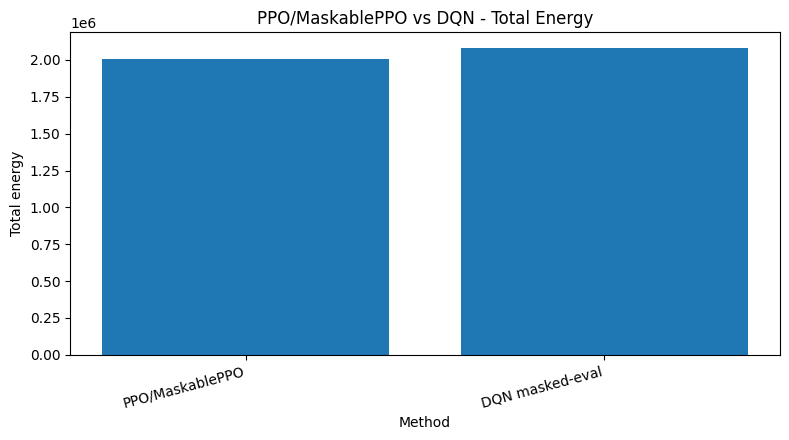

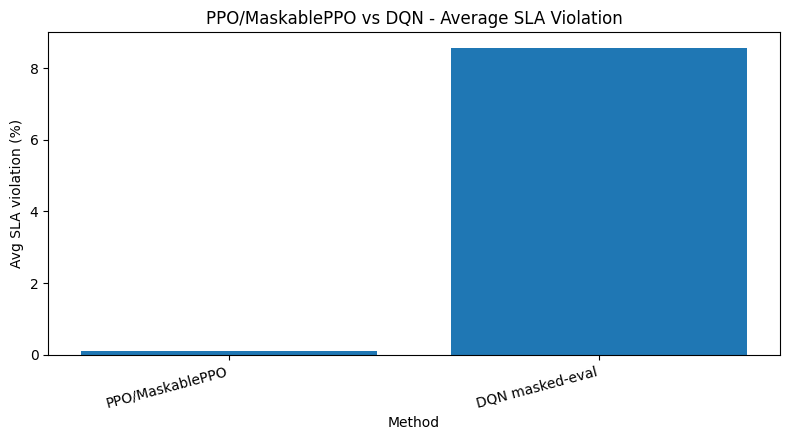

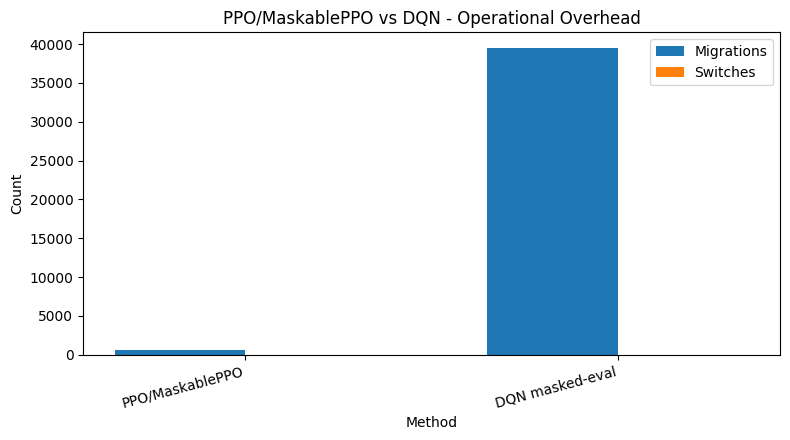

Saved PPO vs DQN figures to: c:\Users\PHUONG NGHI\Desktop\NT549.Q21-DRL-ERM-Cloud\NT549.Q21-DRL-ERM-CLOUD\outputs\dqn_vs_ppo_comparison\dqn_vs_ppo_multiphase_seed66_2500000\figures


In [12]:
main_compare_path = RUN_DIR / "main_drl_comparison_table_seed66.csv"
if main_compare_path.exists():
    main_fig_df = pd.read_csv(main_compare_path)
    display(main_fig_df)

    plt.figure(figsize=(8, 4.5))
    plt.bar(main_fig_df["method"], main_fig_df["total_energy"])
    plt.title("PPO/MaskablePPO vs DQN - Total Energy")
    plt.xlabel("Method")
    plt.ylabel("Total energy")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "04_ppo_vs_dqn_energy.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 4.5))
    plt.bar(main_fig_df["method"], main_fig_df["avg_sla_pct"])
    plt.title("PPO/MaskablePPO vs DQN - Average SLA Violation")
    plt.xlabel("Method")
    plt.ylabel("Avg SLA violation (%)")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "05_ppo_vs_dqn_sla.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 4.5))
    x = np.arange(len(main_fig_df))
    width = 0.35
    plt.bar(x - width/2, main_fig_df["total_migrations"], width, label="Migrations")
    plt.bar(x + width/2, main_fig_df["total_switches"], width, label="Switches")
    plt.title("PPO/MaskablePPO vs DQN - Operational Overhead")
    plt.xlabel("Method")
    plt.ylabel("Count")
    plt.xticks(x, main_fig_df["method"], rotation=15, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "06_ppo_vs_dqn_migration_switch.png", dpi=200)
    plt.show()

    print("Saved PPO vs DQN figures to:", FIG_DIR)
else:
    print("Chưa có main_drl_comparison_table_seed66.csv vì chưa tìm thấy/cấu hình được output PPO. Bỏ qua figure PPO vs DQN.")


## 11. Nhận xét tự động để paste vào báo cáo

In [13]:
def pct(x: float) -> str:
    return f"{100.0 * x:.3f}%"


dqn_summary = results_df[results_df["policy"] == SELECTED_DQN_POLICY].iloc[0]
rr_saving = energy_saving_df.loc[energy_saving_df["baseline"] == "RoundRobin", "energy_saving_pct"]
bf_saving = energy_saving_df.loc[energy_saving_df["baseline"] == "BestFit", "energy_saving_pct"]
rr_saving_val = float(rr_saving.iloc[0]) if len(rr_saving) else float("nan")
bf_saving_val = float(bf_saving.iloc[0]) if len(bf_saving) else float("nan")

low_row = phase_summary_df[(phase_summary_df["policy"] == SELECTED_DQN_POLICY) & (phase_summary_df["phase"] == "low")]
high_row = phase_summary_df[(phase_summary_df["policy"] == SELECTED_DQN_POLICY) & (phase_summary_df["phase"] == "high")]
low_off = float(low_row["avg_off_hosts"].iloc[0]) if len(low_row) else float("nan")
high_off = float(high_row["avg_off_hosts"].iloc[0]) if len(high_row) else float("nan")

base_text = f"""
DQN được huấn luyện như một DRL baseline so sánh với PPO trên workload multiphase với cùng môi trường/reward/config v8.1. 
Ở chế độ DQN_masked_eval, mô hình đạt tổng năng lượng {dqn_summary['total_energy']:.2f}, 
tiết kiệm {rr_saving_val:.2f}% so với RoundRobin và {bf_saving_val:.2f}% so với BestFit. 
Avg SLA violation là {100.0 * float(dqn_summary['avg_sla']):.4f}%, SLA step rate là {100.0 * float(dqn_summary['sla_step_rate']):.2f}%, 
tổng migration là {int(dqn_summary['total_migrations'])}. 
Theo phase, DQN có avg off hosts ở low phase khoảng {low_off:.2f} và ở high phase khoảng {high_off:.2f}.
""".strip()

extra_text = ""
summary_path = RUN_DIR / "dqn_vs_ppo_seed66_summary_metrics.csv"
if summary_path.exists():
    sm = pd.read_csv(summary_path).iloc[0]
    extra_text = f"""

Khi so sánh trực tiếp với PPO/MaskablePPO seed{SEED}, DQN tiêu thụ năng lượng cao hơn PPO khoảng {sm['dqn_energy_gap_vs_ppo_pct']:.2f}%.
PPO có lợi thế năng lượng khoảng {sm['ppo_energy_advantage_over_dqn_pct']:.2f}% so với DQN, trong khi DQN có avg SLA cao hơn khoảng {sm['dqn_sla_over_ppo_ratio']:.2f} lần, migration cao hơn khoảng {sm['dqn_migration_over_ppo_ratio']:.2f} lần và số lần switching cao hơn khoảng {sm['dqn_switch_over_ppo_ratio']:.2f} lần. 
Điều này cho thấy DQN vẫn học được xu hướng tiết kiệm năng lượng, nhưng PPO/MaskablePPO phù hợp hơn với bài toán có action masking và multi-objective reward.
Ghi chú công bằng thí nghiệm: {sm['fairness_note']}
""".strip()

mask_note = """
Do DQN không hỗ trợ action masking trong quá trình training như MaskablePPO, kết quả DQN được dùng như DRL comparison baseline. 
Trong báo cáo chính, nên dùng PPO/MaskablePPO làm mô hình đề xuất và đưa DQN vào mục so sánh/ablation để chứng minh lựa chọn PPO là hợp lý.
""".strip()

report_text = "\n\n".join([base_text, extra_text, mask_note]).strip()

print(report_text)
with open(RUN_DIR / "auto_report_comment_dqn.txt", "w", encoding="utf-8") as f:
    f.write(report_text + "\n")


DQN được huấn luyện như một DRL baseline so sánh với PPO trên workload multiphase với cùng môi trường/reward/config v8.1. 
Ở chế độ DQN_masked_eval, mô hình đạt tổng năng lượng 2083435.65, 
tiết kiệm 20.54% so với RoundRobin và 13.06% so với BestFit. 
Avg SLA violation là 8.5719%, SLA step rate là 52.29%, 
tổng migration là 39534. 
Theo phase, DQN có avg off hosts ở low phase khoảng 0.00 và ở high phase khoảng 0.00.

Khi so sánh trực tiếp với PPO/MaskablePPO seed66, DQN tiêu thụ năng lượng cao hơn PPO khoảng 3.86%.
PPO có lợi thế năng lượng khoảng 3.72% so với DQN, trong khi DQN có avg SLA cao hơn khoảng 82.84 lần, migration cao hơn khoảng 61.48 lần và số lần switching cao hơn khoảng 0.91 lần. 
Điều này cho thấy DQN vẫn học được xu hướng tiết kiệm năng lượng, nhưng PPO/MaskablePPO phù hợp hơn với bài toán có action masking và multi-objective reward.
Ghi chú công bằng thí nghiệm: DQN and PPO have matched training timesteps.

Do DQN không hỗ trợ action masking trong quá trình training nh

## 12. Cách dùng kết quả trong báo cáo

Bảng chính nên dùng:
- `main_drl_comparison_table_seed66.csv`: bảng PPO/MaskablePPO vs DQN masked-eval.
- `dqn_vs_ppo_seed66_summary_metrics.csv`: bảng chênh lệch energy/SLA/migration/switching.
- `phase_summary_dqn_baseline.csv`: phân tích DQN theo low/medium/high phase.

Cách diễn giải ngắn gọn:

> DQN được dùng như một DRL baseline để so sánh với PPO/MaskablePPO. DQN vẫn học được xu hướng giảm năng lượng so với heuristic baselines, nhưng so với PPO, DQN thường có SLA violation, migration và switching cao hơn, đồng thời không tận dụng tốt hành vi Power-Off trong low phase. Điều này cho thấy PPO/MaskablePPO phù hợp hơn với môi trường có action masking và multi-objective reward.

Không nên kết luận “DQN kém tuyệt đối trong mọi bài toán”. Chỉ nên kết luận:

> Trong môi trường mô phỏng và reward của đồ án này, PPO/MaskablePPO phù hợp hơn DQN.
